# 06 X-Window Linear Regression Experiment

Draft experiment notebook for comparing Linear Regression training-window lengths with `2026-06` as the final test month.

This notebook consumes the artifacts from `05_x_window_preprocessing_202606.ipynb` and does not touch the existing Week 4 baseline outputs.


## 0. Setup


In [19]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXPERIMENT_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "x_window_202606"
SPLIT_DIR = EXPERIMENT_DATA_DIR / "splits"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "x_window_202606"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CSV = EXPERIMENT_DATA_DIR / "crmls_xwindow_cleaned.csv"
SPLIT_PLAN_CSV = EXPERIMENT_DATA_DIR / "x_window_split_plan.csv"
TEST_CSV = SPLIT_DIR / "test_2026-06_cleaned.csv"
MODEL_PATH = MODEL_DIR / "linear_regression_x_window_202606_pipeline.joblib"

print(f"Cleaned CSV: {CLEANED_CSV}")
print(f"Split plan: {SPLIT_PLAN_CSV}")
print(f"Output dir: {OUTPUT_DIR}")


Cleaned CSV: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/x_window_202606/crmls_xwindow_cleaned.csv
Split plan: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/x_window_202606/x_window_split_plan.csv
Output dir: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/x_window_202606


## 1. Load Data and Split Plan


In [20]:

CATEGORICAL_DTYPE_COLS = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor", "Levels", "HighSchoolDistrict"]


def normalize_categorical_dtypes(df):
    for col in CATEGORICAL_DTYPE_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("__missing__")
    return df

clean_df = normalize_categorical_dtypes(pd.read_csv(CLEANED_CSV, low_memory=False))
split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})
test_df_raw = normalize_categorical_dtypes(pd.read_csv(TEST_CSV, low_memory=False))

for frame in [clean_df, test_df_raw]:
    if "CloseDate" in frame.columns:
        frame["CloseDate"] = pd.to_datetime(frame["CloseDate"], errors="coerce")
    if "close_month" in frame.columns:
        frame["close_month"] = pd.PeriodIndex(frame["close_month"], freq="M")

historical_plan = split_plan[split_plan["split_type"] == "historical_eval"].copy()
final_plan = split_plan[split_plan["split_type"] == "final_test_candidate"].copy()
candidate_windows = sorted(historical_plan["X_train_months"].astype(int).unique())
historical_eval_months = sorted(historical_plan["eval_month"].astype(str).unique())
final_test_month = final_plan["eval_month"].iloc[0]

display(split_plan)
print(f"Candidate X windows: {candidate_windows}")
print(f"Historical eval months: {historical_eval_months}")
print(f"Final test month: {final_test_month}")


,split_type,X_train_months,train_month_start,train_month_end,train_months,eval_month,train_rows,eval_rows
0,historical_eval,3,2025-04,2025-06,"2025-04, 2025-05, 2025-06",2025-07,35326,12110
1,historical_eval,3,2025-06,2025-08,"2025-06, 2025-07, 2025-08",2025-09,35244,11449
2,historical_eval,3,2025-08,2025-10,"2025-08, 2025-09, 2025-10",2025-11,34911,9720
3,historical_eval,3,2025-11,2026-01,"2025-11, 2025-12, 2026-01",2026-02,27651,8542
4,historical_eval,3,2026-02,2026-04,"2026-02, 2026-03, 2026-04",2026-05,31736,12014
5,historical_eval,6,2025-01,2025-06,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",2025-07,62906,12110
6,historical_eval,6,2025-03,2025-08,"2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2...",2025-09,69477,11449
7,historical_eval,6,2025-05,2025-10,"2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2...",2025-11,70475,9720
8,historical_eval,6,2025-08,2026-01,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2...",2026-02,62562,8542
9,historical_eval,6,2025-11,2026-04,"2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2...",2026-05,59387,12014


Candidate X windows: [np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(18)]
Historical eval months: ['2025-07', '2025-09', '2025-11', '2026-02', '2026-05']
Final test month: 2026-06


## 2. Define Model Features


In [21]:
target = "ClosePrice"

continuous_numeric_cols = ["LivingArea", "LotSizeSquareFeet", "YearBuilt", "Latitude", "Longitude", "AssociationFee"]
count_numeric_cols = ["BedroomsTotal", "BathroomsTotalInteger", "GarageSpaces", "ParkingTotal", "Stories", "Flooring_material_count"]
numeric_cols = continuous_numeric_cols + count_numeric_cols
boolean_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN", "Flooring_Carpet", "Flooring_Tile", "Flooring_Wood", "Flooring_Laminate", "Flooring_Vinyl", "Flooring_Stone", "Flooring_Concrete", "Flooring_Bamboo", "Flooring_Brick", "Flooring_SeeRemarks", "Flooring_multiple_materials_flag"]
categorical_cols = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor", "Levels", "HighSchoolDistrict"]
LOCATION_QUALITY_FLAG_COLS = [
    "Latitude_missing",
    "Longitude_missing",
    "invalid_coordinates_flag",
    "PostalCode_format_issue_flag",
]
flag_cols = [
    col for col in clean_df.columns
    if (col.endswith("_missing") or col.endswith("_flag"))
    and col not in set(boolean_cols)
    and col not in LOCATION_QUALITY_FLAG_COLS
]

numeric_cols = [col for col in numeric_cols if col in clean_df.columns]
boolean_cols = [col for col in boolean_cols if col in clean_df.columns]
categorical_cols = [col for col in categorical_cols if col in clean_df.columns]
flag_cols = [col for col in flag_cols if col in clean_df.columns and col not in {target}]
feature_cols = numeric_cols + categorical_cols + boolean_cols + flag_cols

feature_summary = pd.DataFrame({
    "feature_group": ["numeric", "categorical", "boolean", "flags", "total_raw_model_features"],
    "n_features": [len(numeric_cols), len(categorical_cols), len(boolean_cols), len(flag_cols), len(feature_cols)],
})
display(feature_summary)


,feature_group,n_features
0,numeric,12
1,categorical,6
2,boolean,16
3,flags,26
4,total_raw_model_features,60


## 3. Pipeline and Evaluation Helpers


In [22]:
HIGH_CARDINALITY_CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor"]
HIGH_CARDINALITY_MIN_FREQUENCY = 20
RARE_THRESHOLD_CANDIDATES = [None, 5, 10, 20, 50]


def make_regular_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_high_cardinality_encoder(min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY):
    if min_frequency is None:
        return make_regular_onehot_encoder()
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse=True,
        )


def split_categorical_features(categorical_features):
    high_cardinality_features = [
        col for col in categorical_features
        if col in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    regular_categorical_features = [
        col for col in categorical_features
        if col not in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    return high_cardinality_features, regular_categorical_features


def build_baseline_model(high_cardinality_min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY):
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    high_cardinality_features, regular_categorical_features = split_categorical_features(categorical_cols)
    high_cardinality_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", make_high_cardinality_encoder(high_cardinality_min_frequency)),
    ])
    regular_categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", make_regular_onehot_encoder()),
    ])
    boolean_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])
    flag_pipeline = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0))])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("high_cat", high_cardinality_pipeline, high_cardinality_features),
            ("regular_cat", regular_categorical_pipeline, regular_categorical_features),
            ("bool", boolean_pipeline, boolean_cols),
            ("flag", flag_pipeline, flag_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )
    return Pipeline([("preprocess", preprocessor), ("model", LinearRegression())])

def apply_train_price_bounds(train_df, eval_df, target_col="ClosePrice", lower_q=0.005, upper_q=0.995):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)
    train_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_mask = eval_df[target_col].between(lower_bound, upper_bound)
    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
        },
    )


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    ape = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": ape.mean(),
        "mdape": ape.median(),
    }


def train_month_list(text):
    return [pd.Period(month.strip(), freq="M") for month in str(text).split(",")]


## 4. Historical X-Window Comparison


In [23]:
historical_rows = []

for _, row in historical_plan.iterrows():
    x = int(row["X_train_months"])
    eval_month = pd.Period(str(row["eval_month"]), freq="M")
    train_months = train_month_list(row["train_months"])

    train_df_raw = clean_df[clean_df["close_month"].isin(train_months)].copy()
    eval_df_raw = clean_df[clean_df["close_month"] == eval_month].copy()
    train_df, eval_df, bound_info = apply_train_price_bounds(train_df_raw, eval_df_raw)

    model = build_baseline_model()
    model.fit(train_df[feature_cols], train_df[target])
    pred = model.predict(eval_df[feature_cols])

    historical_rows.append({
        "X_train_months": x,
        "eval_month": str(eval_month),
        "train_month_start": row["train_month_start"],
        "train_month_end": row["train_month_end"],
        "train_months": row["train_months"],
        **bound_info,
        **regression_metrics(eval_df[target], pred),
    })

x_window_results = pd.DataFrame(historical_rows).sort_values(["X_train_months", "eval_month"])
x_window_results.to_csv(OUTPUT_DIR / "x_window_rolling_origin_results.csv", index=False)
display(x_window_results.round(4))


,X_train_months,eval_month,train_month_start,train_month_end,train_months,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,r2,mae,rmse,mape,mdape
0,3,2025-07,2025-04,2025-06,"2025-04, 2025-05, 2025-06",190000.0,8500000.000,35326,34987,12110,11990,0.8347,233530.2450,386146.6121,22.8645,15.8345
1,3,2025-09,2025-06,2025-08,"2025-06, 2025-07, 2025-08",190000.0,8727475.000,35244,34895,11449,11353,0.8167,230057.5414,398281.1103,22.9002,15.6400
2,3,2025-11,2025-08,2025-10,"2025-08, 2025-09, 2025-10",190000.0,8750000.000,34911,34566,9720,9613,0.8146,236446.4263,420216.4474,22.4167,15.9153
3,3,2026-02,2025-11,2026-01,"2025-11, 2025-12, 2026-01",180000.0,9232500.000,27651,27377,8542,8469,0.8080,254878.6865,438343.8941,24.4212,16.9979
4,3,2026-05,2026-02,2026-04,"2026-02, 2026-03, 2026-04",185000.0,9250000.000,31736,31431,12014,11910,0.8287,251417.3295,418356.3825,23.7391,16.3931
5,6,2025-07,2025-01,2025-06,"2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2...",190525.0,8500000.000,62906,62284,12110,11989,0.8401,229796.6117,379701.4582,22.3652,15.6342
6,6,2025-09,2025-03,2025-08,"2025-03, 2025-04, 2025-05, 2025-06, 2025-07, 2...",190000.0,8500000.000,69477,68800,11449,11352,0.8214,228506.4464,392090.6994,22.6523,15.7087
7,6,2025-11,2025-05,2025-10,"2025-05, 2025-06, 2025-07, 2025-08, 2025-09, 2...",190518.0,8665750.000,70475,69769,9720,9611,0.8231,231977.9898,409213.0898,22.2443,15.6199
8,6,2026-02,2025-08,2026-01,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2...",185000.0,9000000.000,62562,61943,8542,8463,0.8222,240689.0313,418736.9902,22.7406,16.0349
9,6,2026-05,2025-11,2026-04,"2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2...",184930.0,9250000.000,59387,58796,12014,11910,0.8332,245858.2461,412910.4655,23.0024,15.9030


In [24]:
x_window_summary = (
    x_window_results
    .groupby("X_train_months", as_index=False)
    .agg(
        n_cutoffs=("eval_month", "nunique"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        min_r2=("r2", "min"),
        max_r2=("r2", "max"),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mape=("mape", "mean"),
        mean_mdape=("mdape", "mean"),
        std_mdape=("mdape", "std"),
    )
    .sort_values(["mean_r2", "std_r2", "mean_mdape"], ascending=[False, True, True])
)

x_window_summary.to_csv(OUTPUT_DIR / "x_window_summary.csv", index=False)
display(x_window_summary.round(4))


,X_train_months,n_cutoffs,mean_r2,std_r2,min_r2,max_r2,mean_mae,mean_rmse,mean_mape,mean_mdape,std_mdape
4,18,5,0.8329,0.0089,0.8263,0.8470,227298.9236,389506.5411,21.6475,15.3043,0.3285
3,12,5,0.8320,0.0083,0.8252,0.8437,230335.5312,395480.7439,21.9790,15.4467,0.3308
2,9,5,0.8300,0.0079,0.8233,0.8410,232375.0144,398285.7018,22.2335,15.5753,0.2916
1,6,5,0.8280,0.0083,0.8214,0.8401,235365.6651,402530.5406,22.6010,15.7802,0.1817
0,3,5,0.8205,0.0109,0.8080,0.8347,241266.0458,412268.8893,23.2684,16.1562,0.5460


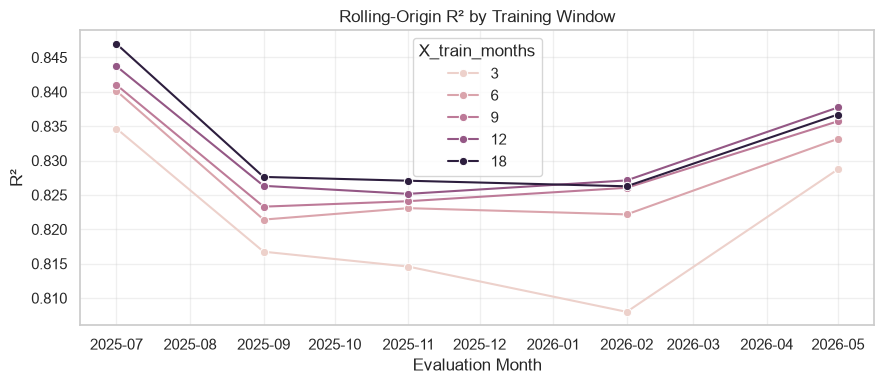

In [25]:
plot_df = x_window_results.copy()
plot_df["eval_month_date"] = pd.to_datetime(plot_df["eval_month"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=plot_df, x="eval_month_date", y="r2", hue="X_train_months", marker="o", ax=ax)
ax.set_title("Rolling-Origin R² by Training Window")
ax.set_xlabel("Evaluation Month")
ax.set_ylabel("R²")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Select X and Evaluate Final Test Once


In [26]:
selected_row = x_window_summary.iloc[0]
selected_x = int(selected_row["X_train_months"])
selected_plan = final_plan[final_plan["X_train_months"].astype(int) == selected_x].iloc[0]
final_train_months = train_month_list(selected_plan["train_months"])

final_train_raw = clean_df[clean_df["close_month"].isin(final_train_months)].copy()
final_test_raw = test_df_raw.copy()
final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(final_train_raw, final_test_raw)

final_model = build_baseline_model()
final_model.fit(final_train_df[feature_cols], final_train_df[target])
train_pred = final_model.predict(final_train_df[feature_cols])
test_pred = final_model.predict(final_test_df[feature_cols])
train_metrics = regression_metrics(final_train_df[target], train_pred)
test_metrics = regression_metrics(final_test_df[target], test_pred)

joblib.dump({
    "model": final_model,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "boolean_cols": boolean_cols,
    "flag_cols": flag_cols,
    "target": target,
    "selected_x": selected_x,
    "price_bounds": {"lower": final_bound_info["price_lower_bound"], "upper": final_bound_info["price_upper_bound"]},
    "train_months": selected_plan["train_months"],
    "test_month": selected_plan["eval_month"],
}, MODEL_PATH)

final_results = pd.DataFrame([{
    "model": "LinearRegression",
    "target": target,
    "selected_X_train_months": selected_x,
    "selection_basis": "highest_mean_historical_r2",
    "historical_mean_r2": selected_row["mean_r2"],
    "historical_std_r2": selected_row["std_r2"],
    "historical_mean_mdape": selected_row["mean_mdape"],
    "final_train_month_start": selected_plan["train_month_start"],
    "final_train_month_end": selected_plan["train_month_end"],
    "final_train_months": selected_plan["train_months"],
    "test_month": selected_plan["eval_month"],
    **final_bound_info,
    "train_r2": train_metrics["r2"],
    "train_mae": train_metrics["mae"],
    "test_r2": test_metrics["r2"],
    "test_mae": test_metrics["mae"],
    "test_rmse": test_metrics["rmse"],
    "test_mape": test_metrics["mape"],
    "test_mdape": test_metrics["mdape"],
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}])

final_results.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)
display(final_results)


,model,target,selected_X_train_months,selection_basis,historical_mean_r2,historical_std_r2,historical_mean_mdape,final_train_month_start,final_train_month_end,final_train_months,test_month,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,train_r2,train_mae,test_r2,test_mae,test_rmse,test_mape,test_mdape,model_path
0,LinearRegression,ClosePrice,18,highest_mean_historical_r2,0.832924,0.008924,15.304293,2024-12,2026-05,"2024-12, 2025-01, 2025-02, 2025-03, 2025-04, 2...",2026-06,189000.0,8750000.0,191942,190039,12858,12713,0.839255,224885.403998,0.839272,232807.807865,396189.18708,21.649688,15.164943,models/linear_regression_x_window_202606_pipel...


## 6. Prediction Diagnostics


In [27]:
predictions = final_test_df[["ListingKey", "CloseDate", "close_month", "CountyOrParish", target]].copy()
predictions["predicted_ClosePrice"] = test_pred
predictions["residual"] = predictions[target] - predictions["predicted_ClosePrice"]
predictions["absolute_error"] = predictions["residual"].abs()
predictions["absolute_percentage_error"] = predictions["absolute_error"] / predictions[target] * 100
predictions.to_csv(OUTPUT_DIR / "test_predictions_linear_regression.csv", index=False)

print(f"Selected X: {selected_x}")
print(f"Train R²: {train_metrics['r2']:.4f}")
print(f"Test R²: {test_metrics['r2']:.4f}")
print(f"Test MAE: ${test_metrics['mae']:,.0f}")
print(f"Test MdAPE: {test_metrics['mdape']:.2f}%")
print(f"Saved outputs to: {OUTPUT_DIR}")
print(f"Saved fitted pipeline to: {MODEL_PATH}")


Selected X: 18
Train R²: 0.8393
Test R²: 0.8393
Test MAE: $232,808
Test MdAPE: 15.16%
Saved outputs to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/x_window_202606
Saved fitted pipeline to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/linear_regression_x_window_202606_pipeline.joblib
